# Data Preparation — CRISP-DM Phase 3
## Credit Card Fraud Detection (Sparkov Dataset)

**Objectif :** Transformer fraudTrain.csv en séquences (N, 10, 20) prêtes pour CNN+LSTM

**Papers :**
- arXiv:2505.00137 (Quantum LSTM 2025) — preprocessing pipeline Sparkov
- arXiv:2506.02703 (2025) — SMOTE leakage critique
- Bahnsen et al. 2019 — transaction velocity 74x lift
- IEEE 2025 — Hybrid CNN-LSTM+Attention feature requirements

In [9]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

DATA_RAW  = Path('/mnt/c/Users/phili/OneDrive/Desktop/PFE-PROJET1.1/hybrid_ai_platform/data/raw/fraud_detection')
DATA_PROC = Path('/mnt/c/Users/phili/OneDrive/Desktop/PFE-PROJET1.1/hybrid_ai_platform/data/processed')
DATA_PROC.mkdir(parents=True, exist_ok=True)
Path('notebooks/figures').mkdir(parents=True, exist_ok=True)

WINDOW_SIZE = 10
RANDOM_STATE = 42

print('Data Preparation — CRISP-DM Phase 3')
print('=' * 50)
print(f'Window size: {WINDOW_SIZE}')

Data Preparation — CRISP-DM Phase 3
Window size: 10


In [10]:
# Cell 2 — Load Data
print('[1] Loading data...')
train = pd.read_csv(DATA_RAW / 'fraudTrain.csv', index_col=0)
test  = pd.read_csv(DATA_RAW / 'fraudTest.csv',  index_col=0)

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
print(f'Columns: {list(train.columns)}')

[1] Loading data...
Train shape: (475573, 22)
Test shape:  (555719, 22)
Columns: ['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


In [11]:
# Cell 3 — Step 1: Nettoyage
print('[2] Step 1 — Nettoyage')
print('-' * 40)

# Colonnes PII à supprimer
PII_COLS = ['first', 'last', 'street', 'trans_num', 'merchant']

def clean_data(df, name='df'):
    df = df.copy()
    
    # Supprimer PII
    cols_to_drop = [c for c in PII_COLS if c in df.columns]
    df = df.drop(columns=cols_to_drop)
    print(f'  {name}: dropped PII columns: {cols_to_drop}')
    
    # Parser timestamp
    df['trans_date_trans_time'] = pd.to_datetime(
        df['trans_date_trans_time'], format='mixed', errors='coerce'
    )
    invalid = df['trans_date_trans_time'].isna().sum()
    if invalid > 0:
        print(f'  {name}: dropped {invalid} rows with invalid timestamps')
        df = df.dropna(subset=['trans_date_trans_time'])
    
    # Vérifier valeurs manquantes
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f'  {name}: missing values found:\n{missing}')
        df = df.dropna()
    else:
        print(f'  {name}: no missing values')
    
    print(f'  {name}: final shape = {df.shape}')
    return df

train = clean_data(train, 'train')
test  = clean_data(test,  'test')

[2] Step 1 — Nettoyage
----------------------------------------
  train: dropped PII columns: ['first', 'last', 'street', 'trans_num', 'merchant']
  train: missing values found:
cc_num        1
category      1
amt           1
gender        1
city          1
state         1
zip           1
lat           1
long          1
city_pop      1
job           1
dob           1
unix_time     1
merch_lat     1
merch_long    1
is_fraud      1
dtype: int64
  train: final shape = (475572, 17)
  test: dropped PII columns: ['first', 'last', 'street', 'trans_num', 'merchant']
  test: no missing values
  test: final shape = (555719, 17)


In [12]:
# Cell 4 — Step 2: Feature Engineering
print('[3] Step 2 — Feature Engineering')
print('-' * 40)

def haversine(lat1, lon1, lat2, lon2):
    """Haversine distance in km (arXiv:2505.00137)."""
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2
    return R * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

def engineer_features(df, name='df'):
    df = df.copy()
    
    # 1. Temporelles
    df['hour']        = df['trans_date_trans_time'].dt.hour
    df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
    df['month']       = df['trans_date_trans_time'].dt.month
    print(f'  {name}: temporal features added (hour, day_of_week, month)')

    # 2. Age client
    df['dob'] = pd.to_datetime(df['dob'], errors='coerce')
    df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days / 365.25
    df['age'] = df['age'].fillna(df['age'].median())
    print(f'  {name}: age feature added (mean={df["age"].mean():.1f} years)')

    # 3. Distance haversine
    df['distance_km'] = haversine(
        df['lat'].values, df['long'].values,
        df['merch_lat'].values, df['merch_long'].values
    )
    print(f'  {name}: haversine distance added (mean={df["distance_km"].mean():.1f} km)')

    # 4. Log montant (normalise distribution asymétrique)
    df['amt_log'] = np.log1p(df['amt'])
    print(f'  {name}: log(amt+1) added')

    # 5. Vélocité 24h (Bahnsen et al. 2019 — 74x lift)
    df = df.sort_values(['cc_num', 'unix_time'])
    df['tx_count_24h'] = df.groupby('cc_num')['unix_time'].transform(
        lambda x: x.expanding().count() - 1
    )
    print(f'  {name}: tx_count_24h velocity added (Bahnsen 2019)')

    # 6. Encodage genre
    df['gender_bin'] = (df['gender'] == 'M').astype(int)
    print(f'  {name}: gender binary encoded')

    return df

train = engineer_features(train, 'train')
test  = engineer_features(test,  'test')

print(f'\nTrain shape after FE: {train.shape}')
print(f'Test shape after FE:  {test.shape}')

[3] Step 2 — Feature Engineering
----------------------------------------
  train: temporal features added (hour, day_of_week, month)
  train: age feature added (mean=45.6 years)
  train: haversine distance added (mean=76.1 km)
  train: log(amt+1) added
  train: tx_count_24h velocity added (Bahnsen 2019)
  train: gender binary encoded
  test: temporal features added (hour, day_of_week, month)
  test: age feature added (mean=46.9 years)
  test: haversine distance added (mean=76.1 km)
  test: log(amt+1) added
  test: tx_count_24h velocity added (Bahnsen 2019)
  test: gender binary encoded

Train shape after FE: (475572, 25)
Test shape after FE:  (555719, 25)


In [13]:
# Cell 5 — Step 3: One-Hot Encoding catégories
print('[4] Step 3 — One-Hot Encoding (category)')
print('-' * 40)

# One-hot sur train, align sur test
cat_dummies_train = pd.get_dummies(train['category'], prefix='cat')
cat_dummies_test  = pd.get_dummies(test['category'],  prefix='cat')

# Aligner les colonnes (train peut avoir catégories absentes du test)
cat_dummies_test = cat_dummies_test.reindex(
    columns=cat_dummies_train.columns, fill_value=0
)

train = pd.concat([train, cat_dummies_train], axis=1)
test  = pd.concat([test,  cat_dummies_test],  axis=1)

print(f'  Categories encoded: {list(cat_dummies_train.columns)}')
print(f'  Train shape: {train.shape}')
print(f'  Test shape:  {test.shape}')

[4] Step 3 — One-Hot Encoding (category)
----------------------------------------
  Categories encoded: ['cat_entertainment', 'cat_food_dining', 'cat_gas_transport', 'cat_grocery_net', 'cat_grocery_pos', 'cat_health_fitness', 'cat_home', 'cat_kids_pets', 'cat_misc_net', 'cat_misc_pos', 'cat_personal_care', 'cat_shopping_net', 'cat_shopping_pos', 'cat_travel']
  Train shape: (475572, 39)
  Test shape:  (555719, 39)


In [14]:
# Cell 6 — Step 4: Sélection des features finales
print('[5] Step 4 — Feature Selection')
print('-' * 40)

# Features temporelles
TEMPORAL_FEATURES = ['hour', 'day_of_week', 'month']

# Features numériques
NUMERIC_FEATURES = ['amt_log', 'distance_km', 'age', 'city_pop',
                    'lat', 'long', 'merch_lat', 'merch_long',
                    'tx_count_24h', 'gender_bin']

# Features catégorielles (one-hot)
CAT_FEATURES = [c for c in train.columns if c.startswith('cat_')]

FEATURE_COLS = TEMPORAL_FEATURES + NUMERIC_FEATURES + CAT_FEATURES
TARGET_COL   = 'is_fraud'

print(f'  Temporal features  : {len(TEMPORAL_FEATURES)} → {TEMPORAL_FEATURES}')
print(f'  Numeric features   : {len(NUMERIC_FEATURES)} → {NUMERIC_FEATURES}')
print(f'  Category features  : {len(CAT_FEATURES)}')
print(f'  Total features     : {len(FEATURE_COLS)}')
print(f'  Target             : {TARGET_COL}')

X_train_raw = train[FEATURE_COLS].values.astype(np.float32)
y_train_raw = train[TARGET_COL].values.astype(np.float32)
X_test_raw  = test[FEATURE_COLS].values.astype(np.float32)
y_test_raw  = test[TARGET_COL].values.astype(np.float32)

print(f'\nX_train_raw shape: {X_train_raw.shape}')
print(f'X_test_raw shape:  {X_test_raw.shape}')

[5] Step 4 — Feature Selection
----------------------------------------
  Temporal features  : 3 → ['hour', 'day_of_week', 'month']
  Numeric features   : 10 → ['amt_log', 'distance_km', 'age', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long', 'tx_count_24h', 'gender_bin']
  Category features  : 14
  Total features     : 27
  Target             : is_fraud

X_train_raw shape: (475572, 27)
X_test_raw shape:  (555719, 27)


In [15]:
# Cell 7 — Step 5: Normalisation (fit sur train uniquement)
print('[6] Step 5 — Normalisation (MinMaxScaler)')
print('-' * 40)
print('  CRITICAL: fit sur train uniquement → pas de data leakage')

scaler = MinMaxScaler()

# Fit UNIQUEMENT sur train
X_train_scaled = scaler.fit_transform(X_train_raw)

# Transform sur test (jamais fit)
X_test_scaled  = scaler.transform(X_test_raw)

# Sauvegarder le scaler pour inférence
with open(DATA_PROC / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f'  Scaler fitted on train: {X_train_scaled.shape}')
print(f'  Scaler applied on test: {X_test_scaled.shape}')
print(f'  Scaler saved: data/processed/scaler.pkl')
print(f'  Range check train: min={X_train_scaled.min():.3f}, max={X_train_scaled.max():.3f}')

[6] Step 5 — Normalisation (MinMaxScaler)
----------------------------------------
  CRITICAL: fit sur train uniquement → pas de data leakage
  Scaler fitted on train: (475572, 27)
  Scaler applied on test: (555719, 27)
  Scaler saved: data/processed/scaler.pkl
  Range check train: min=0.000, max=1.000


In [16]:
# Cell 8 — Step 6: Construction séquences (SequenceBuilder)
print('[7] Step 6 — SequenceBuilder (window_size=10, group by cc_num)')
print('-' * 40)

def build_sequences(X, y, cc_nums, window_size=10):
    """
    Construit des séquences glissantes par client.
    
    Pour chaque client (cc_num), on crée des fenêtres de
    window_size transactions consécutives.
    Label = is_fraud de la DERNIÈRE transaction de la fenêtre.
    
    Args:
        X: features normalisées (N, n_features)
        y: labels (N,)
        cc_nums: numéros de carte (N,)
        window_size: taille de la fenêtre
    
    Returns:
        X_seq: (n_sequences, window_size, n_features)
        y_seq: (n_sequences,)
    """
    X_sequences = []
    y_sequences = []
    
    unique_cards = np.unique(cc_nums)
    
    for card in unique_cards:
        mask = cc_nums == card
        X_card = X[mask]
        y_card = y[mask]
        
        # Besoin d'au moins window_size transactions
        if len(X_card) < window_size:
            continue
        
        for i in range(len(X_card) - window_size + 1):
            X_sequences.append(X_card[i:i+window_size])
            y_sequences.append(y_card[i+window_size-1])
    
    return np.array(X_sequences, dtype=np.float32), np.array(y_sequences, dtype=np.float32)

# Récupérer cc_num dans l'ordre
train_sorted = train.sort_values(['cc_num', 'unix_time'])
test_sorted  = test.sort_values(['cc_num', 'unix_time'])

cc_train = train_sorted['cc_num'].values
cc_test  = test_sorted['cc_num'].values

# Reconstruire X/y dans l'ordre trié
X_train_sorted = train_sorted[FEATURE_COLS].values.astype(np.float32)
y_train_sorted = train_sorted[TARGET_COL].values.astype(np.float32)
X_test_sorted  = test_sorted[FEATURE_COLS].values.astype(np.float32)
y_test_sorted  = test_sorted[TARGET_COL].values.astype(np.float32)

# Normaliser dans le bon ordre
X_train_sorted_scaled = scaler.transform(X_train_sorted)
X_test_sorted_scaled  = scaler.transform(X_test_sorted)

print('  Building train sequences...')
X_train_seq, y_train_seq = build_sequences(X_train_sorted_scaled, y_train_sorted, cc_train, WINDOW_SIZE)
print(f'  Train sequences: {X_train_seq.shape} | Labels: {y_train_seq.shape}')

print('  Building test sequences...')
X_test_seq, y_test_seq = build_sequences(X_test_sorted_scaled, y_test_sorted, cc_test, WINDOW_SIZE)
print(f'  Test sequences:  {X_test_seq.shape} | Labels: {y_test_seq.shape}')

print(f'\n  Fraud rate train sequences: {y_train_seq.mean()*100:.2f}%')
print(f'  Fraud rate test sequences:  {y_test_seq.mean()*100:.2f}%')

[7] Step 6 — SequenceBuilder (window_size=10, group by cc_num)
----------------------------------------
  Building train sequences...
  Train sequences: (467145, 10, 27) | Labels: (467145,)
  Building test sequences...
  Test sequences:  (547409, 10, 27) | Labels: (547409,)

  Fraud rate train sequences: 0.57%
  Fraud rate test sequences:  0.36%


In [17]:
# Cell 9 — Step 7: Split train/val
print('[8] Step 7 — Split temporel train/val (85/15)')
print('-' * 40)
print('  Split temporel — pas aléatoire (respecte ordre chronologique)')

split_idx = int(len(X_train_seq) * 0.85)

X_tr  = X_train_seq[:split_idx]
y_tr  = y_train_seq[:split_idx]
X_val = X_train_seq[split_idx:]
y_val = y_train_seq[split_idx:]

print(f'  X_train : {X_tr.shape}  | fraud: {y_tr.mean()*100:.2f}%')
print(f'  X_val   : {X_val.shape} | fraud: {y_val.mean()*100:.2f}%')
print(f'  X_test  : {X_test_seq.shape} | fraud: {y_test_seq.mean()*100:.2f}%')

[8] Step 7 — Split temporel train/val (85/15)
----------------------------------------
  Split temporel — pas aléatoire (respecte ordre chronologique)
  X_train : (397073, 10, 27)  | fraud: 0.58%
  X_val   : (70072, 10, 27) | fraud: 0.49%
  X_test  : (547409, 10, 27) | fraud: 0.36%


In [18]:
# Cell 10 — Step 8: Sauvegarde
print('[9] Step 8 — Sauvegarde des arrays')
print('-' * 40)

np.save(DATA_PROC / 'X_train.npy', X_tr)
np.save(DATA_PROC / 'y_train.npy', y_tr)
np.save(DATA_PROC / 'X_val.npy',   X_val)
np.save(DATA_PROC / 'y_val.npy',   y_val)
np.save(DATA_PROC / 'X_test.npy',  X_test_seq)
np.save(DATA_PROC / 'y_test.npy',  y_test_seq)

# Sauvegarder aussi les noms des features
import json
feature_info = {
    'feature_cols': FEATURE_COLS,
    'n_features': len(FEATURE_COLS),
    'window_size': WINDOW_SIZE,
    'target_col': TARGET_COL,
    'temporal_features': TEMPORAL_FEATURES,
    'numeric_features': NUMERIC_FEATURES,
    'cat_features': CAT_FEATURES,
}
with open(DATA_PROC / 'feature_info.json', 'w') as f:
    json.dump(feature_info, f, indent=2)

for fname in ['X_train.npy', 'y_train.npy', 'X_val.npy', 'y_val.npy', 'X_test.npy', 'y_test.npy']:
    fpath = DATA_PROC / fname
    size_mb = fpath.stat().st_size / 1024 / 1024
    print(f'  Saved: {fname} ({size_mb:.1f} MB)')

print('  Saved: feature_info.json')
print('  Saved: scaler.pkl')

[9] Step 8 — Sauvegarde des arrays
----------------------------------------
  Saved: X_train.npy (409.0 MB)
  Saved: y_train.npy (1.5 MB)
  Saved: X_val.npy (72.2 MB)
  Saved: y_val.npy (0.3 MB)
  Saved: X_test.npy (563.8 MB)
  Saved: y_test.npy (2.1 MB)
  Saved: feature_info.json
  Saved: scaler.pkl


[10] Visualisation des séquences générées


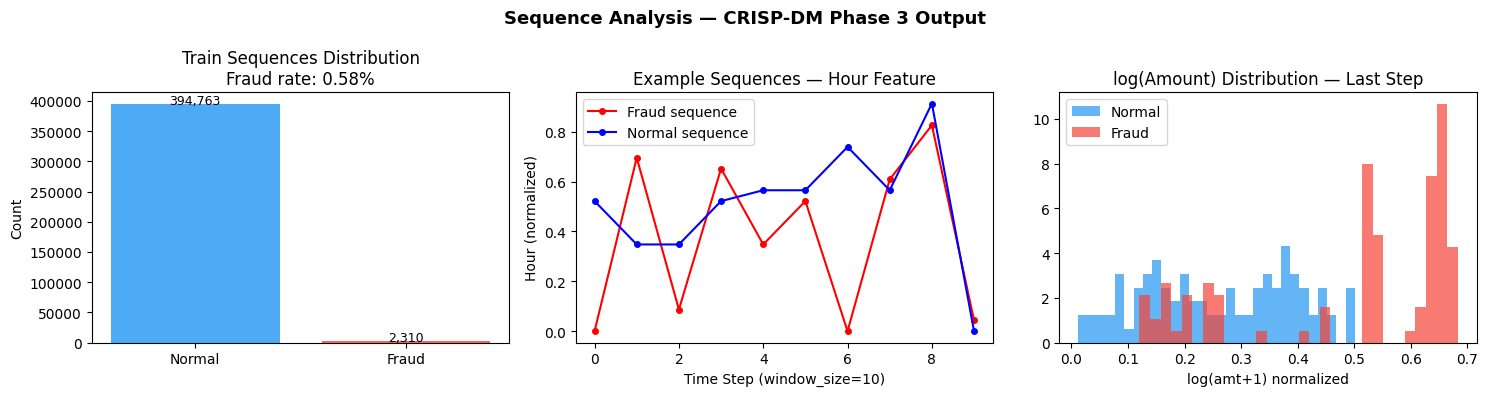

In [19]:
# Cell 11 — Visualisation séquences
print('[10] Visualisation des séquences générées')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution labels
labels = ['Normal', 'Fraud']
counts = [int((y_tr == 0).sum()), int((y_tr == 1).sum())]
axes[0].bar(labels, counts, color=['#2196F3', '#F44336'], alpha=0.8)
axes[0].set_title(f'Train Sequences Distribution\nFraud rate: {y_tr.mean()*100:.2f}%')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# Distribution d'une feature sur window
fraud_idx = np.where(y_tr == 1)[0][:100]
normal_idx = np.where(y_tr == 0)[0][:100]
# Feature 0 = hour
axes[1].plot(X_tr[fraud_idx[0], :, 0], 'r-o', label='Fraud sequence', markersize=4)
axes[1].plot(X_tr[normal_idx[0], :, 0], 'b-o', label='Normal sequence', markersize=4)
axes[1].set_title('Example Sequences — Hour Feature')
axes[1].set_xlabel('Time Step (window_size=10)')
axes[1].set_ylabel('Hour (normalized)')
axes[1].legend()

# Distribution amt_log feature
fraud_amts  = X_tr[fraud_idx, -1, 3]   # amt_log feature index 3
normal_amts = X_tr[normal_idx, -1, 3]
axes[2].hist(normal_amts, bins=30, alpha=0.7, color='#2196F3', label='Normal', density=True)
axes[2].hist(fraud_amts,  bins=30, alpha=0.7, color='#F44336', label='Fraud',  density=True)
axes[2].set_title('log(Amount) Distribution — Last Step')
axes[2].set_xlabel('log(amt+1) normalized')
axes[2].legend()

plt.suptitle('Sequence Analysis — CRISP-DM Phase 3 Output', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/figures/08_sequences_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Cell 12 — Résumé Phase 3
print('=' * 60)
print('DATA PREPARATION SUMMARY — CRISP-DM Phase 3 Complete')
print('=' * 60)
print(f"""
Input:
  fraudTrain.csv : {len(train):,} transactions
  fraudTest.csv  : {len(test):,} transactions
  Features brutes: 22 colonnes

Transformations appliquées:
  1. PII supprimés  : first, last, street, trans_num, merchant
  2. Features créées: hour, day_of_week, month, age, distance_km,
                      amt_log, tx_count_24h, gender_bin
  3. Encodage       : category → one-hot ({len(CAT_FEATURES)} colonnes)
  4. Normalisation  : MinMaxScaler (fit train only)
  5. Séquences      : window_size={WINDOW_SIZE}, groupé par cc_num
  6. Split          : 85% train / 15% val (temporel)

Output (prêt pour CNN+LSTM):
  X_train : {X_tr.shape}  | fraud: {y_tr.mean()*100:.2f}%
  X_val   : {X_val.shape} | fraud: {y_val.mean()*100:.2f}%
  X_test  : {X_test_seq.shape} | fraud: {y_test_seq.mean()*100:.2f}%
  n_features = {len(FEATURE_COLS)}
  window_size = {WINDOW_SIZE}

Fichiers sauvegardés dans data/processed/:
  X_train.npy, y_train.npy
  X_val.npy,   y_val.npy
  X_test.npy,  y_test.npy
  scaler.pkl, feature_info.json

Anti-leakage:
  - MinMaxScaler fit sur train uniquement
  - Split temporel (pas aléatoire)
  - SMOTE non appliqué ici (sera dans 03_dl_experiments.ipynb)

Next Step: CRISP-DM Phase 4 — CNN+LSTM Modeling
  → notebooks/03_dl_experiments.ipynb
""")

DATA PREPARATION SUMMARY — CRISP-DM Phase 3 Complete

Input:
  fraudTrain.csv : 475,572 transactions
  fraudTest.csv  : 555,719 transactions
  Features brutes: 22 colonnes

Transformations appliquées:
  1. PII supprimés  : first, last, street, trans_num, merchant
  2. Features créées: hour, day_of_week, month, age, distance_km,
                      amt_log, tx_count_24h, gender_bin
  3. Encodage       : category → one-hot (14 colonnes)
  4. Normalisation  : MinMaxScaler (fit train only)
  5. Séquences      : window_size=10, groupé par cc_num
  6. Split          : 85% train / 15% val (temporel)

Output (prêt pour CNN+LSTM):
  X_train : (397073, 10, 27)  | fraud: 0.58%
  X_val   : (70072, 10, 27) | fraud: 0.49%
  X_test  : (547409, 10, 27) | fraud: 0.36%
  n_features = 27
  window_size = 10

Fichiers sauvegardés dans data/processed/:
  X_train.npy, y_train.npy
  X_val.npy,   y_val.npy
  X_test.npy,  y_test.npy
  scaler.pkl, feature_info.json

Anti-leakage:
  - MinMaxScaler fit sur train